In [1]:
import os
import time
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch :", torch.__version__)
print("Device  :", device)

PyTorch : 2.11.0+cpu
Device  : cpu


In [2]:
!rm -rf repo dataset

!git clone -q https://github.com/natasyahratu/Computer-Vision-and-Deep-Learning.git repo
!mkdir dataset
!unzip -q repo/dataset_patrol.zip -d dataset

data_path = "dataset/dataset_patrol"

print("Dataset siap")
print(os.listdir(data_path))

Dataset siap
['motorcycle', 'car']


In [3]:
norm = transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225]
)

tf_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    norm
])

tf_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    norm
])

In [4]:
data_all = ImageFolder(data_path, tf_test)
data_train = ImageFolder(data_path, tf_train)
data_eval = ImageFolder(data_path, tf_test)

print("Kelas :", data_all.classes)
print("Total :", len(data_all))

assert len(data_all) == 114

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    len(data_all),
    generator=generator
).tolist()

train_idx = indices[:92]
val_idx = indices[92:103]
test_idx = indices[103:114]

train_set = Subset(data_train, train_idx)
val_set = Subset(data_eval, val_idx)
test_set = Subset(data_eval, test_idx)

print("Train :", len(train_set))
print("Val   :", len(val_set))
print("Test  :", len(test_set))

Kelas : ['car', 'motorcycle']
Total : 114
Train : 92
Val   : 11
Test  : 11


In [5]:
train_loader = DataLoader(
    train_set,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=8,
    shuffle=False
)

In [6]:
def buat_model(scratch=False):

    if scratch:
        model = models.resnet50(weights=None)
    else:
        model = models.resnet50(
            weights=ResNet50_Weights.DEFAULT
        )

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model.to(device)

In [7]:
def train(mode, epochs=10):

    torch.manual_seed(42)

    if mode == "scratch":
        model = buat_model(scratch=True)
    else:
        model = buat_model(scratch=False)

    if mode == "feature":

        for p in model.parameters():
            p.requires_grad = False

        for p in model.fc.parameters():
            p.requires_grad = True

    elif mode == "partial":

        for p in model.parameters():
            p.requires_grad = False

        for p in model.layer4.parameters():
            p.requires_grad = True

        for p in model.fc.parameters():
            p.requires_grad = True

    else:  # full / scratch

        for p in model.parameters():
            p.requires_grad = True

    if mode == "feature":

        optimizer = torch.optim.Adam(
            model.fc.parameters(),
            lr=1e-3
        )

    elif mode == "partial":

        optimizer = torch.optim.Adam([
            {"params": model.layer4.parameters(), "lr": 1e-4},
            {"params": model.fc.parameters(), "lr": 1e-3}
        ])

    elif mode == "full":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-5
        )

    else:

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-3
        )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    criterion = nn.CrossEntropyLoss()

    train_acc = []
    val_acc = []

    terbaik = -1
    mulai = time.time()


    for epoch in range(1, epochs + 1):

        model.train()

        if mode == "feature":

            for nama, bagian in model.named_children():
                if nama != "fc":
                    bagian.eval()

        elif mode == "partial":

            for nama, bagian in model.named_children():
                if nama != "layer4" and nama != "fc":
                    bagian.eval()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            output = model(images)

            loss = criterion(output, labels)

            loss.backward()
            optimizer.step()

            correct += (
                output.argmax(1) == labels
            ).sum().item()

            total += labels.size(0)

        train_accuracy = correct / total
        train_acc.append(train_accuracy)

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                output = model(
                    images.to(device)
                )

                correct += (
                    output.argmax(1).cpu() == labels
                ).sum().item()

                total += labels.size(0)

        val_accuracy = correct / total
        val_acc.append(val_accuracy)

        scheduler.step()

        print(
            f"{mode} | epoch {epoch}/{epochs} | "
            f"train {train_accuracy:.3f} | "
            f"val {val_accuracy:.3f}"
        )

        if val_accuracy > terbaik:

            terbaik = val_accuracy

            torch.save(
                model.state_dict(),
                mode + "_best.pt"
            )

    waktu = round(time.time() - mulai)

    ep90 = None

    for i, acc in enumerate(val_acc):

        if acc >= 0.90:
            ep90 = i + 1
            break

    model.load_state_dict(
        torch.load(mode + "_best.pt")
    )


    model.eval()

    asli = []
    tebak = []

    with torch.no_grad():

        for images, labels in test_loader:

            output = model(
                images.to(device)
            )

            asli += labels.tolist()

            tebak += (
                output.argmax(1)
                .cpu()
                .tolist()
            )

    test = sum(
        a == t for a, t in zip(asli, tebak)
    ) / len(asli)

    print(
        f"Akurasi val terbaik: {terbaik:.3f} | "
        f"Akurasi test: {test:.3f}"
    )

    return {
        "mode": mode,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_terbaik": terbaik,
        "ep90": ep90,
        "test": test,
        "waktu": waktu,
        "model": model,
        "conf": confusion_matrix(
            asli,
            tebak,
            labels=[0, 1]
        ).tolist()
    }

In [8]:
hasil_mode1 = train("feature")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


feature | epoch 1/10 | train 0.957 | val 1.000
feature | epoch 2/10 | train 1.000 | val 1.000
feature | epoch 3/10 | train 1.000 | val 1.000
feature | epoch 4/10 | train 1.000 | val 1.000
feature | epoch 5/10 | train 1.000 | val 1.000
feature | epoch 6/10 | train 1.000 | val 1.000
feature | epoch 7/10 | train 1.000 | val 1.000
feature | epoch 8/10 | train 1.000 | val 1.000
feature | epoch 9/10 | train 1.000 | val 1.000
feature | epoch 10/10 | train 1.000 | val 1.000
Akurasi val terbaik: 1.000 | Akurasi test: 1.000


In [9]:
hasil_mode2 = train("partial")

partial | epoch 1/10 | train 0.815 | val 1.000
partial | epoch 2/10 | train 0.978 | val 1.000
partial | epoch 3/10 | train 1.000 | val 1.000
partial | epoch 4/10 | train 0.989 | val 1.000
partial | epoch 5/10 | train 1.000 | val 1.000
partial | epoch 6/10 | train 1.000 | val 1.000
partial | epoch 7/10 | train 0.989 | val 1.000
partial | epoch 8/10 | train 1.000 | val 1.000
partial | epoch 9/10 | train 0.989 | val 1.000
partial | epoch 10/10 | train 1.000 | val 1.000
Akurasi val terbaik: 1.000 | Akurasi test: 1.000


In [10]:
hasil_mode3 = train("full")

full | epoch 1/10 | train 0.522 | val 0.545
full | epoch 2/10 | train 0.663 | val 0.727
full | epoch 3/10 | train 0.913 | val 0.818
full | epoch 4/10 | train 0.902 | val 0.818
full | epoch 5/10 | train 0.913 | val 0.818
full | epoch 6/10 | train 0.913 | val 1.000
full | epoch 7/10 | train 0.957 | val 1.000
full | epoch 8/10 | train 0.967 | val 1.000
full | epoch 9/10 | train 0.946 | val 1.000
full | epoch 10/10 | train 0.989 | val 1.000
Akurasi val terbaik: 1.000 | Akurasi test: 0.909


In [11]:
hasil_mode4 = train("scratch")

scratch | epoch 1/10 | train 0.500 | val 0.545
scratch | epoch 2/10 | train 0.489 | val 0.364
scratch | epoch 3/10 | train 0.587 | val 0.818
scratch | epoch 4/10 | train 0.554 | val 0.545
scratch | epoch 5/10 | train 0.630 | val 0.636
scratch | epoch 6/10 | train 0.750 | val 0.545
scratch | epoch 7/10 | train 0.793 | val 0.727
scratch | epoch 8/10 | train 0.772 | val 0.727
scratch | epoch 9/10 | train 0.837 | val 0.545
scratch | epoch 10/10 | train 0.826 | val 0.818
Akurasi val terbaik: 0.818 | Akurasi test: 0.455


In [12]:
def evaluasi(model):

    model.eval()

    y_true = []
    y_pred = []

    mulai = time.time()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            output = model(images)

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                output.argmax(1)
                .cpu()
                .numpy()
            )

    if device.type == "cuda":
        torch.cuda.synchronize()

    latency = (
        (time.time() - mulai)
        / len(test_set)
        * 1000
    )

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Latency (ms/image)": latency
    }

In [13]:
hasil = [
    hasil_mode1,
    hasil_mode2,
    hasil_mode3,
    hasil_mode4
]

tabel = pd.DataFrame(hasil)[
    ["mode", "val_terbaik", "ep90", "test", "waktu"]
]

tabel.columns = [
    "Mode",
    "Akurasi val terbaik",
    "Epoch pertama val >= 90%",
    "Akurasi test",
    "Waktu latih (s)"
]

tabel

,Mode,Akurasi val terbaik,Epoch pertama val >= 90%,Akurasi test,Waktu latih (s)
0,feature,1.000000,1.0,1.000000,260
1,partial,1.000000,1.0,1.000000,341
2,full,1.000000,6.0,0.909091,695
3,scratch,0.818182,NaN,0.454545,690


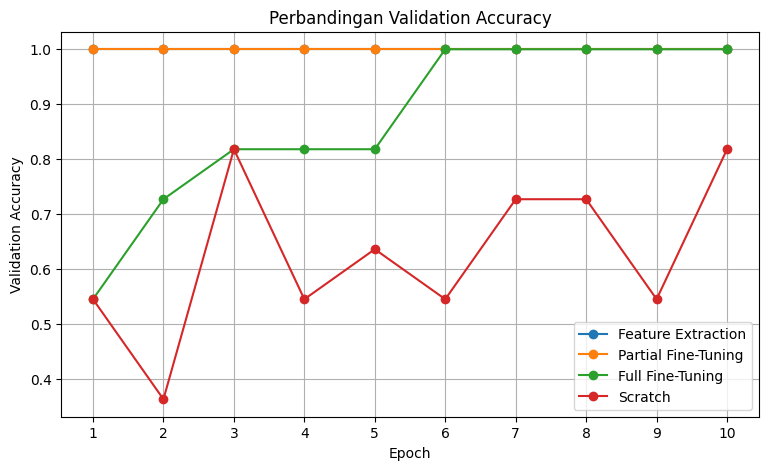

In [14]:
epochs = range(1, 11)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    hasil_mode1["val_acc"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    epochs,
    hasil_mode2["val_acc"],
    marker="o",
    label="Partial Fine-Tuning"
)

plt.plot(
    epochs,
    hasil_mode3["val_acc"],
    marker="o",
    label="Full Fine-Tuning"
)

plt.plot(
    epochs,
    hasil_mode4["val_acc"],
    marker="o",
    label="Scratch"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.show()

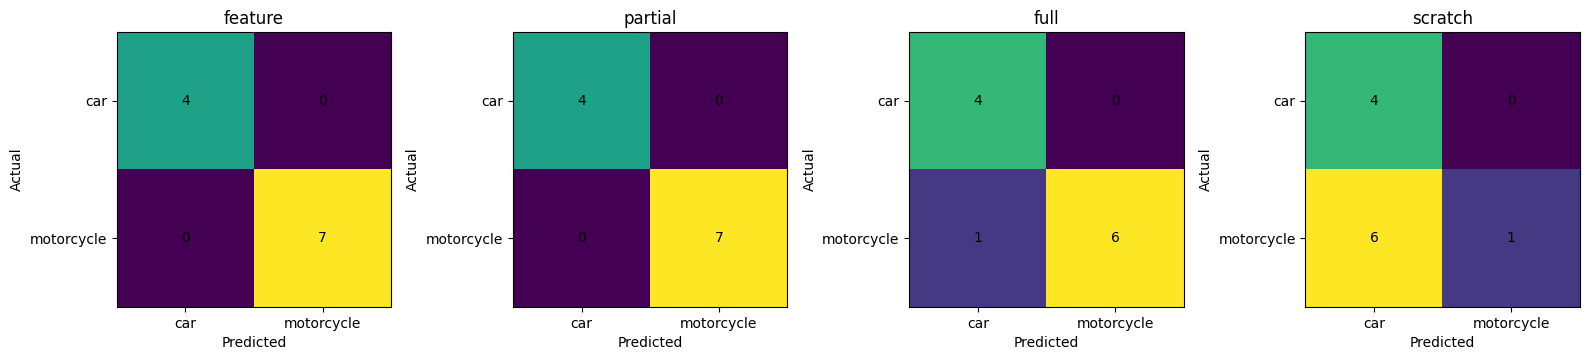

In [15]:
hasil_model = [
    hasil_mode1,
    hasil_mode2,
    hasil_mode3,
    hasil_mode4
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

for ax, hasil in zip(axes, hasil_model):

    model = hasil["model"]

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            output = model(
                images.to(device)
            )

            y_true += labels.tolist()

            y_pred += (
                output.argmax(1)
                .cpu()
                .tolist()
            )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    ax.imshow(cm)

    ax.set_title(hasil["mode"])

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        data_all.classes
    )

    ax.set_yticklabels(
        data_all.classes
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()